<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EA%B0%9C%EB%A1%A0_8%EC%B0%A8%EC%8B%9C_01_bi_cls_20260310.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이진 분류

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [1]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [2]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot

In [3]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## 6.5 시그모이드 함수

In [4]:
np.arange(-4, 4.1, 0.25)
x_np = np.arange(-4, 4.1, 0.25)
torch.tensor(x_np).float()

tensor([-4.0000, -3.7500, -3.5000, -3.2500, -3.0000, -2.7500, -2.5000, -2.2500,
        -2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000,  2.2500,  2.5000,  2.7500,  3.0000,  3.2500,  3.5000,  3.7500,
         4.0000])

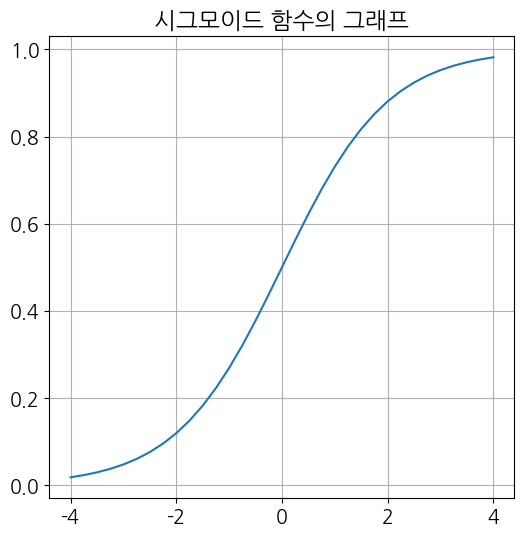

In [5]:
# 넘파이 배열로 x_np를 정의
x_np = np.arange(-4, 4.1, 0.25)

# x_np를 텐서로 변환
x = torch.tensor(x_np).float()

# y값 계산
y = torch.sigmoid(x)

# 그래프 출력
plt.title('시그모이드 함수의 그래프')
plt.plot(x.data, y.data)
plt.show()

## 6.7 데이터 준비

In [6]:
# 필요한 라이브러리를 가져옵니다.
from sklearn.datasets import load_iris

# iris 데이터를 불러옵니다.
iris = load_iris()

# 입력 데이터(꽃의 특징)와 정답 데이터(꽃의 종류)를 분리합니다.
x_org, y_org = iris.data, iris.target

# 원본 데이터의 크기를 확인합니다. (총 150개의 데이터, 4개의 특징)
print('--- 1. 데이터 불러오기 결과 ---')
print('원본 데이터', x_org.shape, y_org.shape) #(150, 4) (150,)

--- 1. 데이터 불러오기 결과 ---
원본 데이터 (150, 4) (150,)


In [8]:
y_org

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
print(iris.data.shape)
print(iris.target.shape)

(150, 4)
(150,)


In [10]:
iris.data
iris.data[:100, :2].shape

(100, 2)

In [11]:
# --- 2. 데이터 추출 ---
# 이진 분류를 위해, 두 종류의 꽃 데이터(100개)와 두 개의 특징(꽃받침 길이/너비)만 사용합니다.
x_data = iris.data[:100, :2] # (100,2)
y_data = iris.target[:100] #(100,)

# 추출한 데이터의 크기를 확인합니다. (총 100개의 데이터, 2개의 특징)
print('--- 2. 데이터 추출 결과 ---')
print('대상 데이터', x_data.shape, y_data.shape) #(100, 2) (100,)

--- 2. 데이터 추출 결과 ---
대상 데이터 (100, 2) (100,)


### 훈련 데이터와 검증 데이터 분할

In [12]:
# --- 3. 훈련 데이터와 검증 데이터로 분할 ---
# 데이터를 훈련용 70개, 검증용 30개로 나눕니다.
# train_test_split 함수는 데이터를 무작위로 섞어주므로 편향을 방지할 수 있습니다.
# random_state=123으로 설정하여 실행할 때마다 동일한 결과를 얻도록 합니다.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, train_size=70, test_size=30, random_state=42)

# 분할된 데이터들의 크기를 최종 확인합니다.
print('--- 3. 데이터 분할 결과 ---')
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape) #(70, 2) (30, 2) (70,) (30,)

--- 3. 데이터 분할 결과 ---
(70, 2) (30, 2) (70,) (30,)


### 훈련 데이터의 산포도 출력

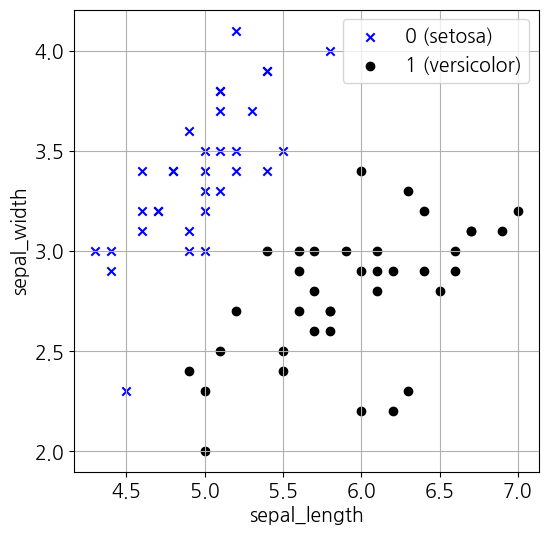

In [13]:
# 산포도 출력

x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='b', label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='k', label='1 (versicolor)')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()

## 6.8 모델 정의

In [14]:
x_train[1]

array([4.6, 3.2])

In [15]:
# --- 1. 입출력 차원수 정의 ---
# 입력 특징은 2개(꽃받침 길이, 너비)입니다.
n_input = x_train.shape[1]
# 출력은 1개(클래스 '1'일 확률)입니다.
n_output = 1
print(f'n_input: {n_input}, n_output: {n_output}')

n_input: 2, n_output: 1


In [16]:
# --- 2. 모델 클래스 정의 ---
# 2입력 1출력 로지스틱 회귀 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()  # 상속
        self.l1 = nn.Linear(n_input, n_output) # 선형함수 사용
        self.sigmoid = nn.Sigmoid() # 시그모이드 사용(통과)

        # 가중치와 편향을 1로 초기화합니다.
        # (일반적인 경우에는 무작위 값으로 초기화합니다.)
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    # 데이터가 모델을 통과하는 흐름(순전파)을 정의합니다. (예측 함수 정의)
    def forward(self, x):
        x1 = self.l1(x) # 선형 함수 적용
        x2 = self.sigmoid(x1) # 시그모이드 함수 적용
        return x2

In [18]:
# --- 3. 모델 개요 확인 ---
# 모델의 인스턴스를 생성합니다.
net = Net(n_input, n_output)
net

Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

### 모델 확인

In [19]:
# 모델 안의 파라미터 확인
# l1.weight와 l1.bias가 존재함을 알 수 있음

for parameter in net.named_parameters():
    print(parameter)

# y= wx + b 선형함수 기본 모델
# >> y_pred = (1)x1 + (1)x2 + 1

('l1.weight', Parameter containing:
tensor([[1., 1.]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([1.], requires_grad=True))


In [20]:
# 모델의 개요 표시 1

print(net)

Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [21]:
# 모델의 개요 표시 2

summary(net, (2,))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       3
├─Sigmoid: 1-2                           [1]                       --
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### 최적화 알고리즘과 손실 함수의 정의

In [22]:
# 손실 함수로 이진 교차 엔트로피(Binary Cross Entropy)를 사용합니다.
criterion = nn.BCELoss()

# 학습률(learning rate)을 설정합니다.
lr = 0.01

# 최적화 함수로 확률적 경사 하강법(Stochastic Gradient Descent)을 사용합니다.
optimizer = optim.SGD(net.parameters(), lr=lr)

## 6.9 경사 하강법

In [23]:
x_train[:10]

array([[4.8, 3.4],
       [4.6, 3.2],
       [6. , 3.4],
       [5.2, 3.4],
       [5. , 2.3],
       [5.4, 3.9],
       [5.6, 3. ],
       [6.7, 3.1],
       [5. , 3.2],
       [5.4, 3.9]])

In [24]:
torch.tensor(x_train).float()[:10]

tensor([[4.8000, 3.4000],
        [4.6000, 3.2000],
        [6.0000, 3.4000],
        [5.2000, 3.4000],
        [5.0000, 2.3000],
        [5.4000, 3.9000],
        [5.6000, 3.0000],
        [6.7000, 3.1000],
        [5.0000, 3.2000],
        [5.4000, 3.9000]])

In [26]:
# 입력 데이터 x_train과 정답 데이터 y_train의 텐서화

inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).float()

# 정답 데이터는 N행 1열 행렬로 변환
labels1 = labels.view((-1,1))

# 검증 데이터의 텐서화
inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).float()

# 검증용 정답 데이터도 N행 1열 행렬로 변환
labels1_test = labels_test.view((-1,1))

In [27]:
labels[:10]

tensor([0., 0., 1., 0., 1., 0., 1., 1., 0., 0.])

In [28]:
labels.view((-1,1)) # why? (N,1) 파이토치는 (batch_size, features)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.]])

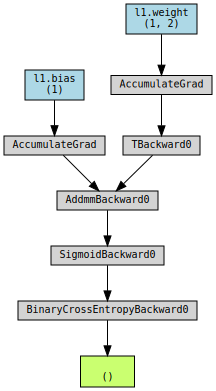

In [29]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels1)

# 손실을 계산 그래프로 출력
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

### 반복 계산

In [30]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.BCELoss()

# 최적화 함수: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 기록용 리스트 초기화
history = np.zeros((0,5))

In [31]:
np.zeros((0,5))

array([], shape=(0, 5), dtype=float64)

In [32]:
# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # --- 훈련 페이즈 ---
    optimizer.zero_grad()      # 경삿값 초기화
    outputs = net(inputs)      # 예측 계산
    loss = criterion(outputs, labels1) # 손실 계산
    loss.backward()            # 경사 계산
    optimizer.step()           # 파라미터 수정

    train_loss = loss.item()   # 손실 저장 (스칼라 값 취득)
    # 확률값을 0.5 기준으로 0 또는 1로 변환
    predicted = torch.where(outputs < 0.5, 0, 1)
    # 정확도 계산
    train_acc = (predicted == labels1).sum() / len(y_train)

    # --- 예측(검증) 페이즈 ---
    # 여기서는 경사 계산과 파라미터 수정이 필요 없습니다.
    outputs_test = net(inputs_test) # 예측 계산
    loss_test = criterion(outputs_test, labels1_test) # 손실 계산
    val_loss = loss_test.item() # 손실 저장
    predicted_test = torch.where(outputs_test < 0.5, 0, 1) # 예측 라벨(1 또는 0) 계산
    val_acc = (predicted_test == labels1_test).sum() / len(y_test) # 정확도 계산

    # 1000번에 한 번씩 결과 출력
    if (epoch % 1000 == 0):
        print(f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f}, acc: {train_acc:.5f}, val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')

    # 기록
    item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
    history = np.vstack((history, item))

Epoch [0/10000], loss: 4.41008, acc: 0.52857, val_loss: 5.33157, val_acc: 0.43333
Epoch [1000/10000], loss: 0.39246, acc: 0.98571, val_loss: 0.37537, val_acc: 1.00000
Epoch [2000/10000], loss: 0.26725, acc: 0.98571, val_loss: 0.24387, val_acc: 1.00000
Epoch [3000/10000], loss: 0.21065, acc: 0.98571, val_loss: 0.18562, val_acc: 1.00000
Epoch [4000/10000], loss: 0.17855, acc: 0.98571, val_loss: 0.15268, val_acc: 1.00000
Epoch [5000/10000], loss: 0.15782, acc: 0.98571, val_loss: 0.13133, val_acc: 1.00000
Epoch [6000/10000], loss: 0.14329, acc: 0.98571, val_loss: 0.11625, val_acc: 1.00000
Epoch [7000/10000], loss: 0.13252, acc: 0.98571, val_loss: 0.10496, val_acc: 1.00000
Epoch [8000/10000], loss: 0.12419, acc: 0.98571, val_loss: 0.09614, val_acc: 1.00000
Epoch [9000/10000], loss: 0.11755, acc: 0.98571, val_loss: 0.08904, val_acc: 1.00000


## 6.10 결과 확인

In [33]:
history

array([[   0.    ,    4.4101,    0.5286,    5.3316,    0.4333],
       [   1.    ,    4.3275,    0.5286,    5.2299,    0.4333],
       [   2.    ,    4.245 ,    0.5286,    5.1281,    0.4333],
       ...,
       [9997.    ,    0.1121,    0.9857,    0.0832,    1.    ],
       [9998.    ,    0.1121,    0.9857,    0.0832,    1.    ],
       [9999.    ,    0.1121,    0.9857,    0.0832,    1.    ]])

In [37]:
# 손실과 정확도 확인

print('--- 최종 결과 ---')
print(f'초기 상태(검증) : 손실: {history[0, 3]:.5f}, 정확도: {history[0, 4]:.5f}')
print(f'최종 상태(검증) : 손실: {history[-1, 3]:.5f}, 정확도: {history[-1, 4]:.5f}')

--- 최종 결과 ---
초기 상태(검증) : 손실: 5.33157, 정확도: 0.43333
최종 상태(검증) : 손실: 0.08318, 정확도: 1.00000


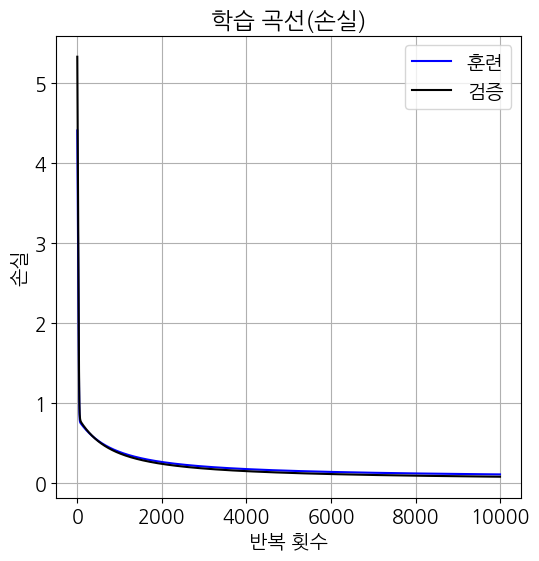

In [38]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

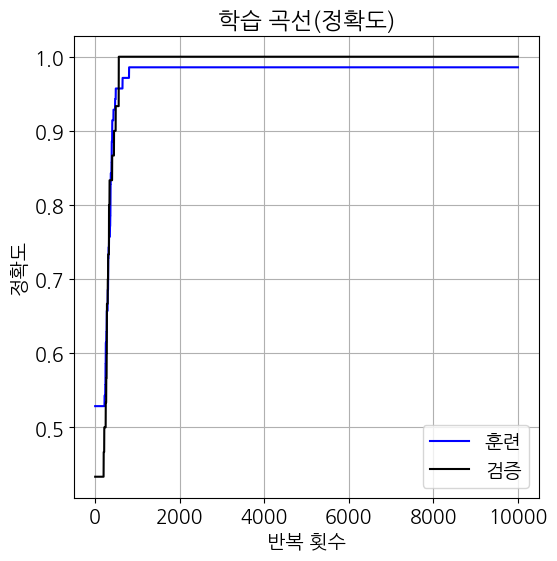

In [39]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

### 결정  경계 그래프 출력

In [40]:
y_test == 0
x_test[y_test==0]

array([[4.8, 3. ],
       [5.1, 3.8],
       [5.1, 3.4],
       [4.6, 3.6],
       [5.4, 3.7],
       [5.1, 3.5],
       [5.7, 3.8],
       [4.8, 3.1],
       [5.5, 4.2],
       [5. , 3.6],
       [4.8, 3. ],
       [5.4, 3.4],
       [5. , 3.4],
       [4.4, 3.2],
       [5.7, 4.4],
       [5. , 3.5],
       [4.9, 3.1]])

In [41]:
# 검증 데이터 준비

x_t0 = x_test[y_test==0]
x_t1 = x_test[y_test==1]

In [43]:
net.l1.bias
net.l1.bias.data.numpy()

array([-0.1045], dtype=float32)

In [44]:
# 파라미터 취득

bias = net.l1.bias.data.numpy()
weight = net.l1.weight.data.numpy()
print(f'BIAS = {bias}, WEIGHT = {weight}')

# 결정 경계를 그리기 위해 x1로부터 x2를 계산
def decision(x):
    return(-(bias + weight[0,0] * x)/ weight[0,1])

# 산포도의 x1의 최솟값과 최댓값
xl = np.array([x_test[:,0].min(), x_test[:,0].max()])
yl = decision(xl)

# 결과 확인
print(f'xl = {xl}  yl = {yl}')

BIAS = [-0.1045], WEIGHT = [[ 2.9509 -5.115 ]]
xl = [4.4 6.8]  yl = [2.518  3.9026]


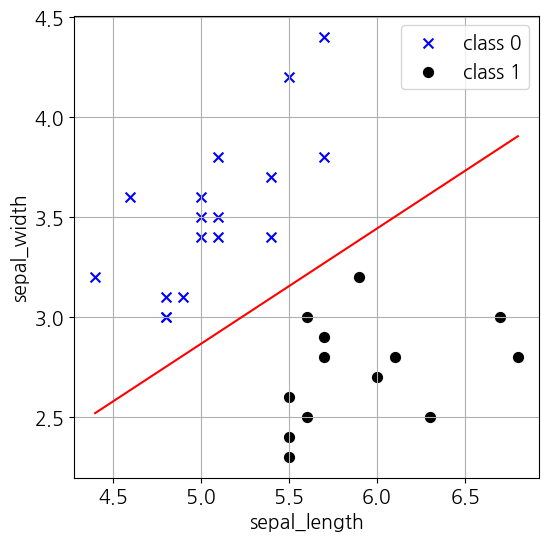

In [45]:
# 산포도 출력
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x',
        c='b', s=50, label='class 0')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o',
        c='k', s=50, label='class 1')

# 결정 경계 직선
plt.plot(xl, yl, c='r')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()

## 칼럼 BCELoss 함수와 BCEWithLogitsLoss 함수의 차이

In [46]:
# 모델 정의
# 2입력 1출력 로지스틱 회귀 모델

class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)

        # 초깃값을 모두 1로 함
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    # 예측 함수 정의
    def forward(self, x):
        # 입력 값과 행렬 곱을 계산
        x1 = self.l1(x)
        return x1

In [47]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수 ： logits가 붙은 교차 엔트로피 함수
criterion = nn.BCEWithLogitsLoss()

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 기록용 리스트 초기화
history = np.zeros((0,5))

In [48]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):
    # 훈련 페이즈

    # 경삿값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 손실 계산
    loss = criterion(outputs, labels1)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()

    # 손실값 스칼라화
    train_loss = loss.item()

    # 예측 라벨(1 또는 0) 계산
    predicted = torch.where(outputs < 0.0, 0, 1)

    # 정확도 계산
    train_acc = (predicted == labels1).sum() / len(y_train)

    # 예측 페이즈

    # 예측 계산
    outputs_test = net(inputs_test)

    # 손실 계산
    loss_test = criterion(outputs_test, labels1_test)

    # 손실값 스칼라화
    val_loss =  loss_test.item()

    # 예측 라벨(1 또는 0) 계산
    predicted_test = torch.where(outputs_test < 0.0, 0, 1)

    # 정확도 계산
    val_acc = (predicted_test == labels1_test).sum() / len(y_test)

    if ( epoch % 1000 == 0):
        print (f'Epoch [{epoch}/{num_epochs}], loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [0/10000], loss: 4.41009 acc: 0.52857 val_loss: 5.33163, val_acc: 0.43333
Epoch [1000/10000], loss: 0.39246 acc: 0.98571 val_loss: 0.37537, val_acc: 1.00000
Epoch [2000/10000], loss: 0.26725 acc: 0.98571 val_loss: 0.24387, val_acc: 1.00000
Epoch [3000/10000], loss: 0.21065 acc: 0.98571 val_loss: 0.18562, val_acc: 1.00000
Epoch [4000/10000], loss: 0.17855 acc: 0.98571 val_loss: 0.15268, val_acc: 1.00000
Epoch [5000/10000], loss: 0.15782 acc: 0.98571 val_loss: 0.13133, val_acc: 1.00000
Epoch [6000/10000], loss: 0.14329 acc: 0.98571 val_loss: 0.11625, val_acc: 1.00000
Epoch [7000/10000], loss: 0.13252 acc: 0.98571 val_loss: 0.10496, val_acc: 1.00000
Epoch [8000/10000], loss: 0.12419 acc: 0.98571 val_loss: 0.09614, val_acc: 1.00000
Epoch [9000/10000], loss: 0.11755 acc: 0.98571 val_loss: 0.08904, val_acc: 1.00000


In [49]:
# 손실과 정확도 확인

print(f'초기 상태 : 손실 : {history[0,3]:.5f}  정확도 : {history[0,4]:.5f}' )
print(f'최종 상태 : 손실 : {history[-1,3]:.5f}  정확도 : {history[-1,4]:.5f}' )

초기 상태 : 손실 : 5.33163  정확도 : 0.43333
최종 상태 : 손실 : 0.08904  정확도 : 1.00000


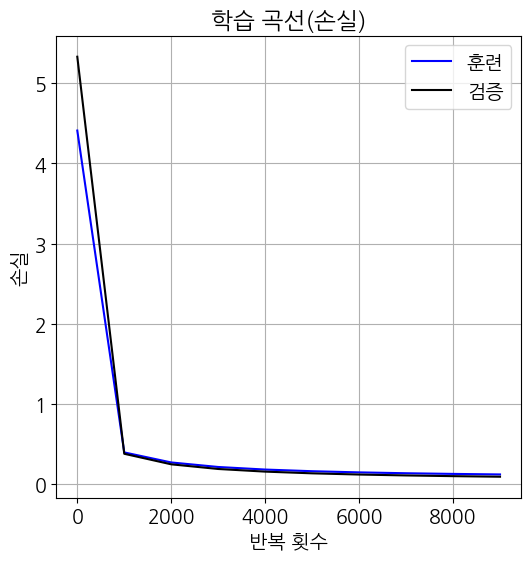

In [50]:
# 학습 곡선 표시(손실)

plt.plot(history[:,0], history[:,1], 'b', label='훈련')
plt.plot(history[:,0], history[:,3], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.legend()
plt.show()

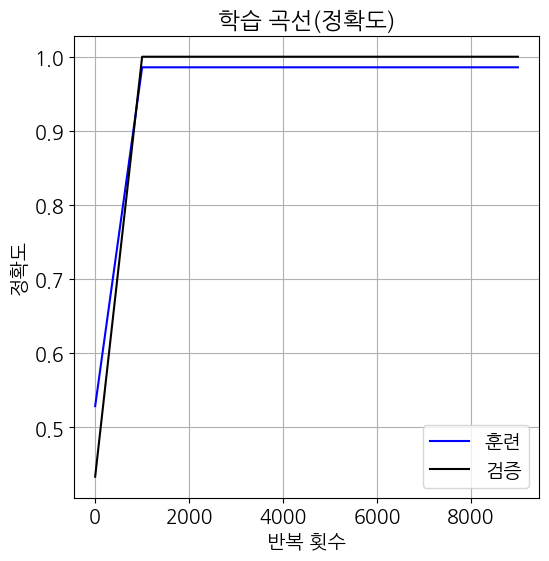

In [51]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], 'b', label='훈련')
plt.plot(history[:,0], history[:,4], 'k', label='검증')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.title('학습 곡선(정확도)')
plt.legend()
plt.show()

In [52]:
# 파라미터 취득

bias = net.l1.bias.data.numpy()
weight = net.l1.weight.data.numpy()
print(f'BIAS = {bias}, WEIGHT = {weight}')

# 결정 경계를 그리기 위해 x1로부터 x2를 계산
def decision(x):
    return(-(bias + weight[0,0] * x)/ weight[0,1])

# 산포도의 x1의 최솟값과 최댓값
xl = np.array([x_test[:,0].min(), x_test[:,0].max()])
yl = decision(xl)

# 결과 확인
print(f'xl = {xl}  yl = {yl}')

BIAS = [-0.1045], WEIGHT = [[ 2.9509 -5.115 ]]
xl = [4.4 6.8]  yl = [2.518  3.9026]


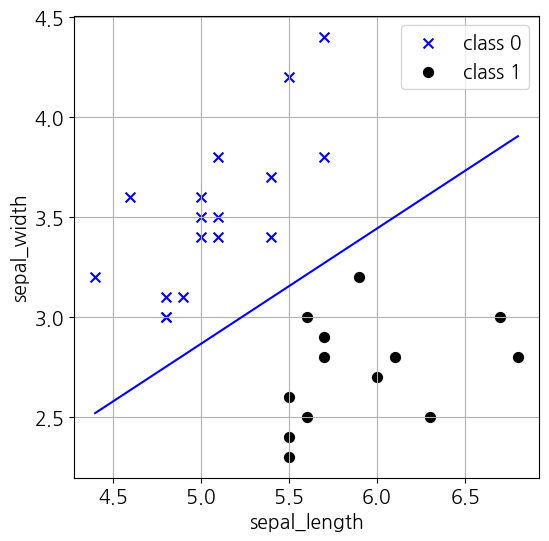

In [53]:
# 산포도 출력
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x',
        c='b', s=50, label='class 0')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o',
        c='k', s=50, label='class 1')

# 결정 경계 직선
plt.plot(xl, yl, c='b')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()

In [ ]:
#eos

[정리]

1. BCELoss
- nn.Linear() >> nn.Sigmoid (2단계)
- 손실 임계값 y값은 [0,1], 0.5(threshold)
- 수치 안정성 : 낮음

2. BCEWithLoss
- nn.Linear()1단계 (nn.Sigmoid 내장)
- 손실 임계값 0(threshold)
- 수치 안정성 : 높음